# Analyse des illustrations classées cuivre

**Projet** : Gallica Images — Classification gravures sur bois vs cuivre  
**Date**   : Avril 2026

Ce notebook analyse les résultats des modèles v1 et v2 appliqués aux
9200 résultats de similarité Salomon. Il produit des visualisations
destinées à Céline Bohnert pour valider manuellement les illustrations
classées cuivre.

**Entrée**  : `resultats/csv/salomon_enrichi_segmente.csv`  
**Sortie**  : `resultats/visualisations/bois_cuivre_recherche_avec_segmentation/*.png`

---


## 1. Configuration

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

CHEMIN_CSV = "../../resultats/csv/salomon_enrichi_segmente.csv"
DOSSIER_VIZ = "../../resultats/visualisations/bois_cuivre_recherche_avec_segmentation"
os.makedirs(DOSSIER_VIZ, exist_ok=True)

df = pd.read_csv(CHEMIN_CSV)
print(f"✓ CSV chargé : {df.shape[0]} lignes")
print(f"  Colonnes IA : {[c for c in df.columns if 'technique_ia' in c]}")

✓ CSV chargé : 8300 lignes
  Colonnes IA : ['technique_ia_v1', 'technique_ia_conf_v1', 'technique_ia_v2', 'technique_ia_conf_v2']


## 2. Statistiques générales

In [10]:
df_cuivre_v1 = df[df["technique_ia_v1"] == "cuivre"].copy()
df_cuivre_v2 = df[df["technique_ia_v2"] == "cuivre"].copy()
df_accord    = df[(df["technique_ia_v1"] == "cuivre") &
                  (df["technique_ia_v2"] == "cuivre")].copy()
df_v1_seul   = df[(df["technique_ia_v1"] == "cuivre") &
                  (df["technique_ia_v2"] != "cuivre")].copy()
df_v2_seul   = df[(df["technique_ia_v2"] == "cuivre") &
                  (df["technique_ia_v1"] != "cuivre")].copy()

print("=" * 50)
print("STATISTIQUES GÉNÉRALES")
print("=" * 50)
print(f"  Total résultats         : {len(df):,}")
print(f"  Cuivres v1              : {len(df_cuivre_v1)}")
print(f"  Cuivres v2              : {len(df_cuivre_v2)}")
print(f"  Accord v1 + v2          : {len(df_accord)} — cas les plus certains")
print(f"  Détectés par v1 seul    : {len(df_v1_seul)}")
print(f"  Détectés par v2 seul    : {len(df_v2_seul)}")
print(f"  Pages Salomon concernées: {df_accord['salomon_page'].nunique()}")

STATISTIQUES GÉNÉRALES
  Total résultats         : 8,300
  Cuivres v1              : 1666
  Cuivres v2              : 1602
  Accord v1 + v2          : 1296 — cas les plus certains
  Détectés par v1 seul    : 370
  Détectés par v2 seul    : 306
  Pages Salomon concernées: 157


## 3. Figure 1 — Répartition par corpus

Si un corpus est connu comme étant uniquement sur bois, une barre haute est suspecte.

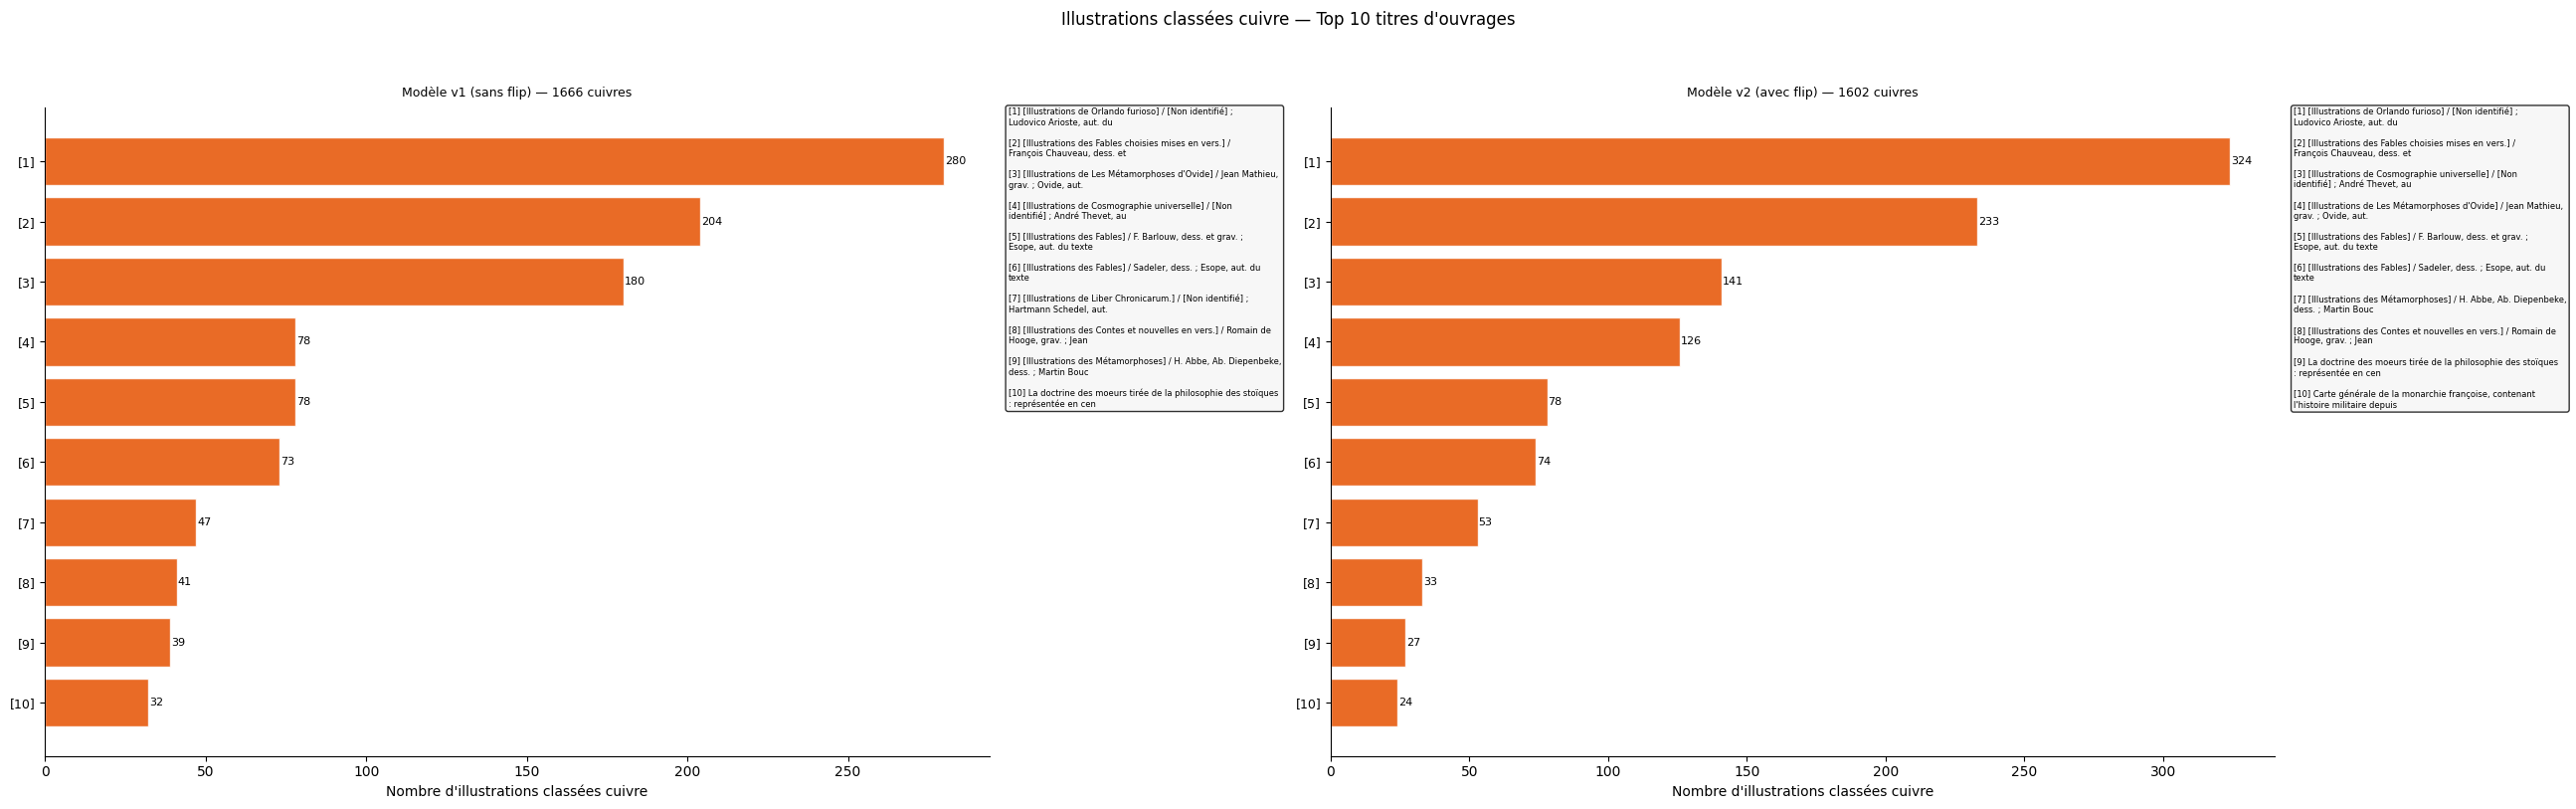

✓ Figure 1 sauvegardée


In [11]:
import textwrap

# ── Figure 1 — Top 10 titres v1 et v2 ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(26, 8))
fig.suptitle(
    "Illustrations classées cuivre — Top 10 titres d'ouvrages\n",
    fontsize=12, y=1.01
)

for ax, (df_v, label) in zip(axes, [
    (df_cuivre_v1, f"Modèle v1 (sans flip) — {len(df_cuivre_v1)} cuivres"),
    (df_cuivre_v2, f"Modèle v2 (avec flip) — {len(df_cuivre_v2)} cuivres")
]):
    titre_counts  = df_v["titre"].value_counts().head(10)
    labels_courts = [f"[{i+1}]" for i in range(len(titre_counts))]

    bars = ax.barh(
        range(len(titre_counts)),
        titre_counts.values,
        color="#e65100", alpha=0.85, edgecolor="white"
    )
    ax.set_yticks(range(len(titre_counts)))
    ax.set_yticklabels(labels_courts, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Nombre d'illustrations classées cuivre")
    ax.set_title(label, fontsize=9, pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar, val in zip(bars, titre_counts.values):
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=8)

    legende = "\n\n".join(
        [f"[{i+1}] {textwrap.fill(str(t), width=60)}"
         for i, t in enumerate(titre_counts.index)]
    )
    ax.text(1.02, 1.0, legende,
            transform=ax.transAxes,
            fontsize=6, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="#f5f5f5", alpha=0.8))

plt.tight_layout()
plt.savefig(f"{DOSSIER_VIZ}/01_repartition_titres.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure 1 sauvegardée")

## 4. Figure 2 — Accord v1 + v2 par corpus

Les corpus classés cuivre par les **deux** modèles — cas les plus certains à valider en priorité.

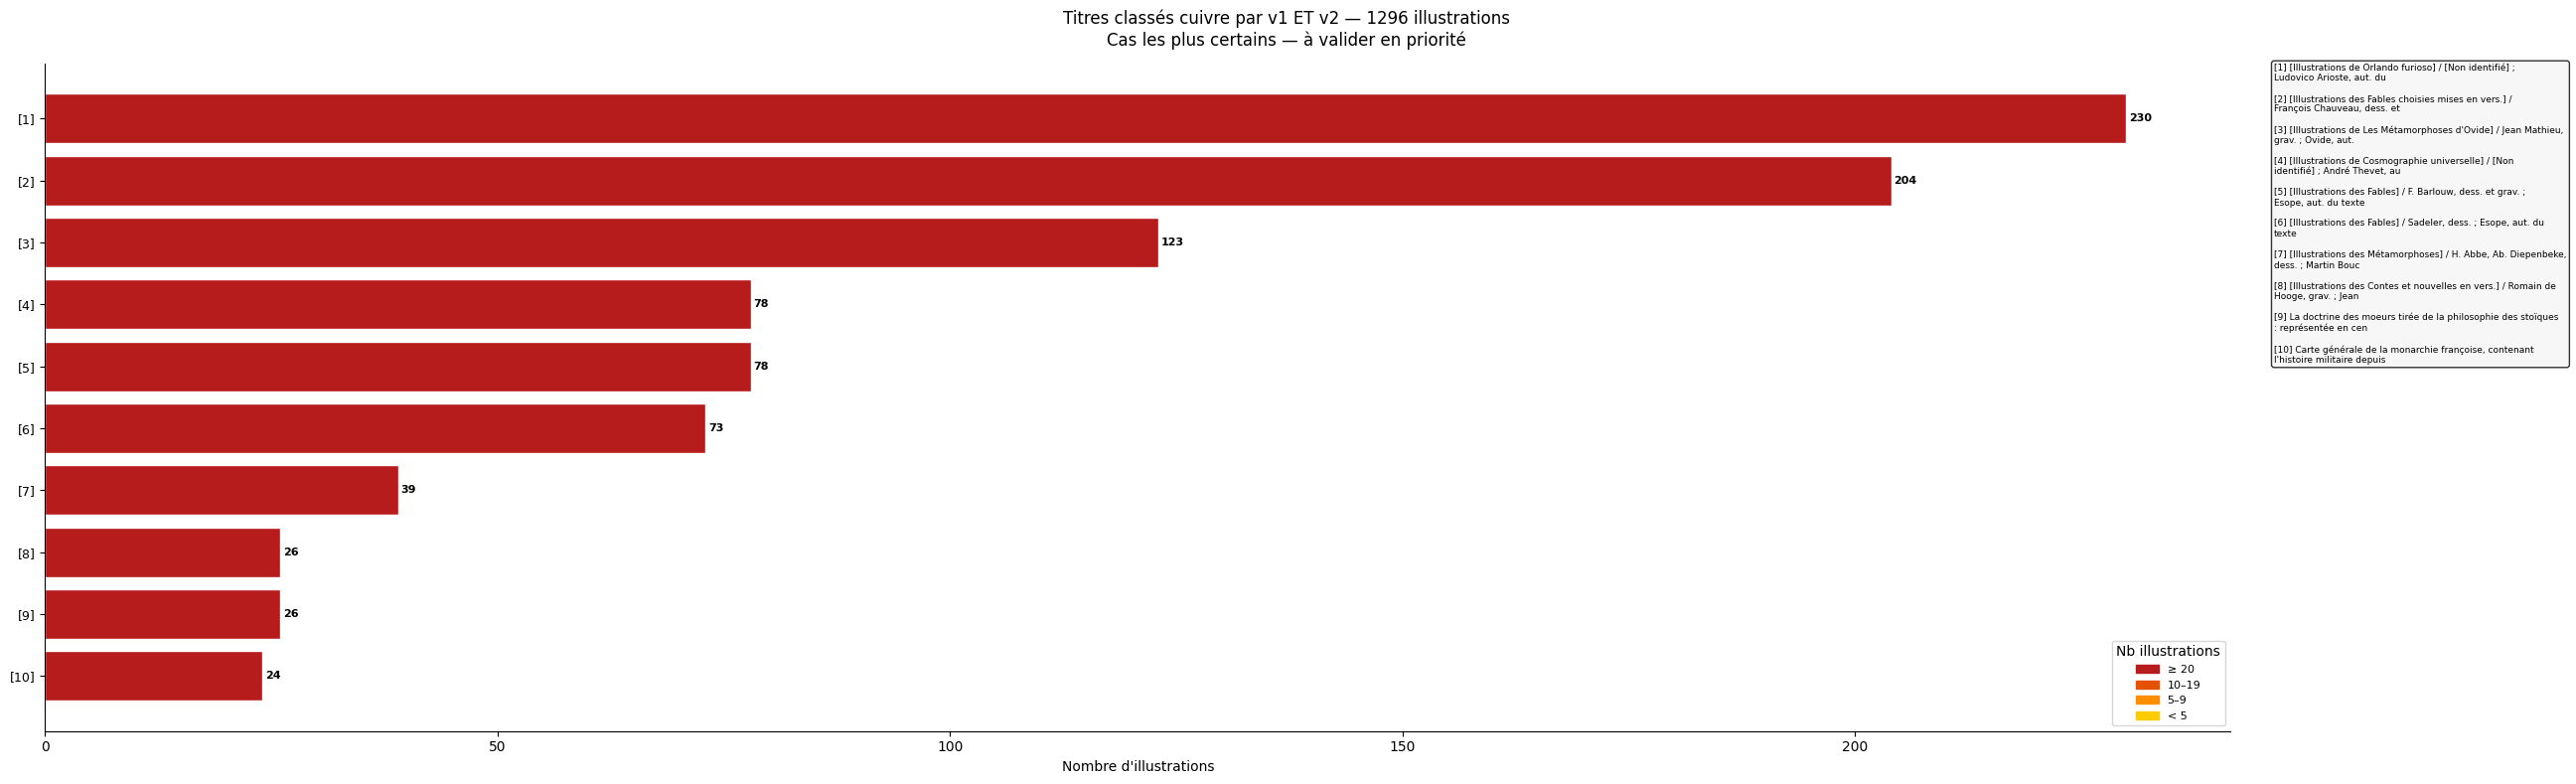

✓ Figure 2 sauvegardée


In [12]:
# ── Figure 2 — Accord v1 + v2 par titre ─────────────────────
fig, ax = plt.subplots(figsize=(26, 8))
fig.suptitle(
    f"Titres classés cuivre par v1 ET v2 — {len(df_accord)} illustrations\n"
    "Cas les plus certains — à valider en priorité",
    fontsize=12
)

titre_accord  = df_accord["titre"].value_counts().head(10)
labels_courts = [f"[{i+1}]" for i in range(len(titre_accord))]

colors = [
    "#b71c1c" if v >= 20 else
    "#e65100" if v >= 10 else
    "#ff8f00" if v >= 5  else
    "#ffcc02"
    for v in titre_accord.values
]

bars = ax.barh(
    range(len(titre_accord)),
    titre_accord.values,
    color=colors, edgecolor="white"
)
ax.set_yticks(range(len(titre_accord)))
ax.set_yticklabels(labels_courts, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Nombre d'illustrations")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, val in zip(bars, titre_accord.values):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=8, fontweight="bold")

legende = "\n\n".join(
    [f"[{i+1}] {textwrap.fill(str(t), width=60)}"
     for i, t in enumerate(titre_accord.index)]
)
ax.text(1.02, 1.0, legende,
        transform=ax.transAxes,
        fontsize=6.5, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="#f5f5f5", alpha=0.8))

patches = [
    mpatches.Patch(color="#b71c1c", label="≥ 20"),
    mpatches.Patch(color="#e65100", label="10–19"),
    mpatches.Patch(color="#ff8f00", label="5–9"),
    mpatches.Patch(color="#ffcc02", label="< 5"),
]
ax.legend(handles=patches, title="Nb illustrations",
          loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(f"{DOSSIER_VIZ}/02_accord_v1_v2_titres.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure 2 sauvegardée")

## 5. Figure 3 — Différences entre v1 et v2 par corpus

Cuivre v1 / Bois v2 : 370 illustrations
Cuivre v2 / Bois v1 : 301 illustrations


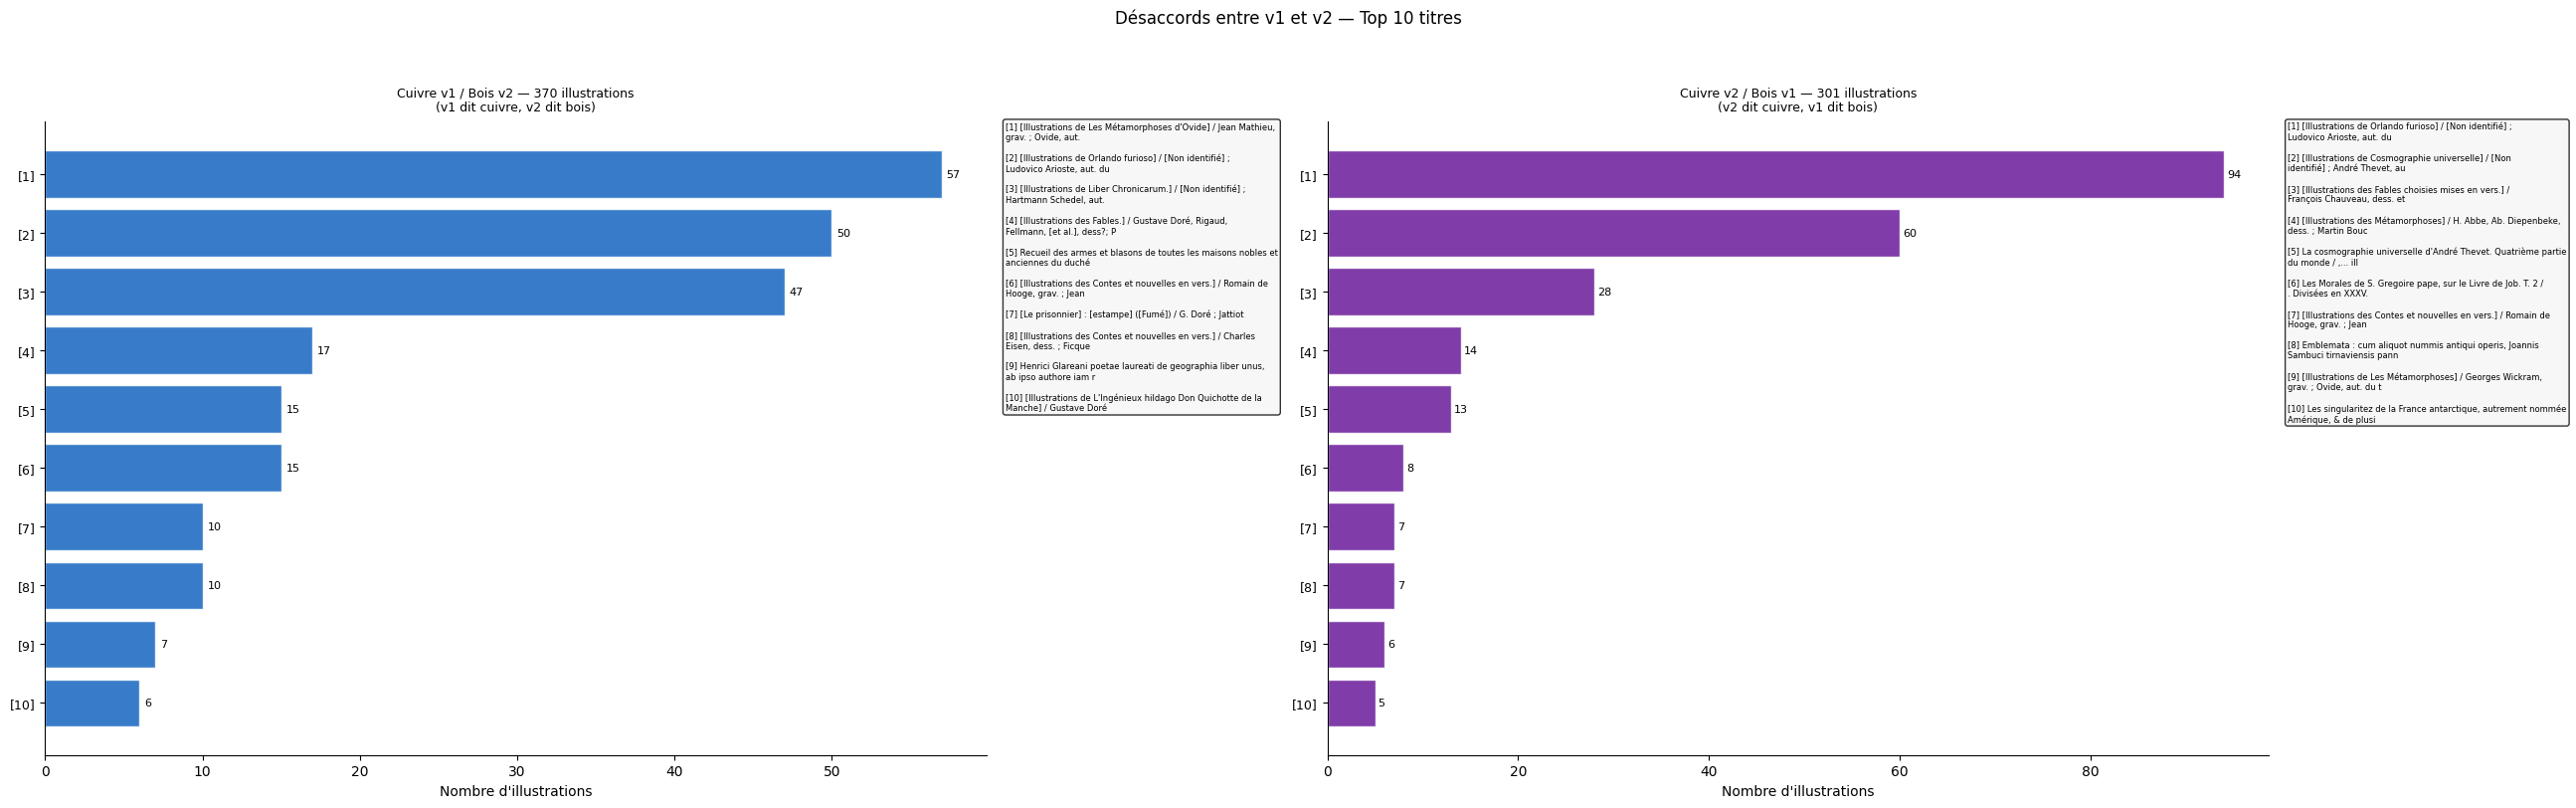

✓ Figure 6 sauvegardée


In [13]:
# ── Différences entre v1 et v2 ───────────────────────────────
df_v1_seul = df[(df["technique_ia_v1"] == "cuivre") &
                (df["technique_ia_v2"] == "bois")].copy()

df_v2_seul = df[(df["technique_ia_v2"] == "cuivre") &
                (df["technique_ia_v1"] == "bois")].copy()

print(f"Cuivre v1 / Bois v2 : {len(df_v1_seul)} illustrations")
print(f"Cuivre v2 / Bois v1 : {len(df_v2_seul)} illustrations")

fig, axes = plt.subplots(1, 2, figsize=(26, 8))
fig.suptitle(
    "Désaccords entre v1 et v2 — Top 10 titres\n",
    fontsize=12, y=1.01
)

for ax, (df_v, label, color) in zip(axes, [
    (df_v1_seul,
     f"Cuivre v1 / Bois v2 — {len(df_v1_seul)} illustrations\n"
     "(v1 dit cuivre, v2 dit bois)",
     "#1565c0"),
    (df_v2_seul,
     f"Cuivre v2 / Bois v1 — {len(df_v2_seul)} illustrations\n"
     "(v2 dit cuivre, v1 dit bois)",
     "#6a1b9a"),
]):
    if len(df_v) == 0:
        ax.text(0.5, 0.5, "Aucun désaccord",
                ha="center", va="center", transform=ax.transAxes, fontsize=12)
        ax.set_title(label, fontsize=9)
        continue

    titre_counts  = df_v["titre"].value_counts().head(10)
    labels_courts = [f"[{i+1}]" for i in range(len(titre_counts))]

    bars = ax.barh(
        range(len(titre_counts)),
        titre_counts.values,
        color=color, alpha=0.85, edgecolor="white"
    )
    ax.set_yticks(range(len(titre_counts)))
    ax.set_yticklabels(labels_courts, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Nombre d'illustrations")
    ax.set_title(label, fontsize=9, pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar, val in zip(bars, titre_counts.values):
        ax.text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=8)

    legende = "\n\n".join(
        [f"[{i+1}] {textwrap.fill(str(t), width=60)}"
         for i, t in enumerate(titre_counts.index)]
    )
    ax.text(1.02, 1.0, legende,
            transform=ax.transAxes,
            fontsize=6, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="#f5f5f5", alpha=0.8))

plt.tight_layout()
plt.savefig(f"{DOSSIER_VIZ}/06_desaccords_v1_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure 6 sauvegardée")